In [89]:
#libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

In [90]:
#data loading

data1 = pd.read_csv('train.csv')
data2 = pd.read_csv('test.csv')

train_df = data1.copy()
test_df = data2.copy()

print("First 5 rows of train_df: \n", train_df.head())

print("First 5 rows of test_df: \n", test_df.head())

First 5 rows of train_df: 
    id  annual_income  debt_to_income_ratio  credit_score  loan_amount  \
0   0       29367.99                 0.084           736      2528.42   
1   1       22108.02                 0.166           636      4593.10   
2   2       49566.20                 0.097           694     17005.15   
3   3       46858.25                 0.065           533      4682.48   
4   4       25496.70                 0.053           665     12184.43   

   interest_rate  gender marital_status education_level employment_status  \
0          13.67  Female         Single     High School     Self-employed   
1          12.92    Male        Married        Master's          Employed   
2           9.76    Male         Single     High School          Employed   
3          16.10  Female         Single     High School          Employed   
4          10.21    Male        Married     High School          Employed   

         loan_purpose grade_subgrade  loan_paid_back  
0              

In [91]:
train_df = train_df.drop(columns=['id'], axis=1)

test_id_placeholder = test_df['id']
test_df = test_df.drop(columns=['id'], axis=1)

In [92]:
#feature engineering

train_df['in_relationship'] = (train_df['marital_status'] == 'Married').astype(int)
test_df['in_relationship'] = (test_df['marital_status'] == 'Married').astype(int)

train_df['in_debt'] = (train_df['loan_purpose'] == 'Debt consolidation').astype(int)
test_df['in_debt'] = (test_df['loan_purpose'] == 'Debt consolidation').astype(int)

In [93]:
cat_cols = train_df.select_dtypes(exclude='number')

In [94]:
cat_cols

,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade
0,Female,Single,High School,Self-employed,Other,C3
1,Male,Married,Master's,Employed,Debt consolidation,D3
2,Male,Single,High School,Employed,Debt consolidation,C5
3,Female,Single,High School,Employed,Debt consolidation,F1
4,Male,Married,High School,Employed,Other,D1
...,...,...,...,...,...,...
593989,Female,Single,High School,Employed,Business,C3
593990,Male,Single,Bachelor's,Employed,Debt consolidation,F5
593991,Female,Married,Bachelor's,Employed,Debt consolidation,C1
593992,Male,Single,Bachelor's,Employed,Debt consolidation,B2


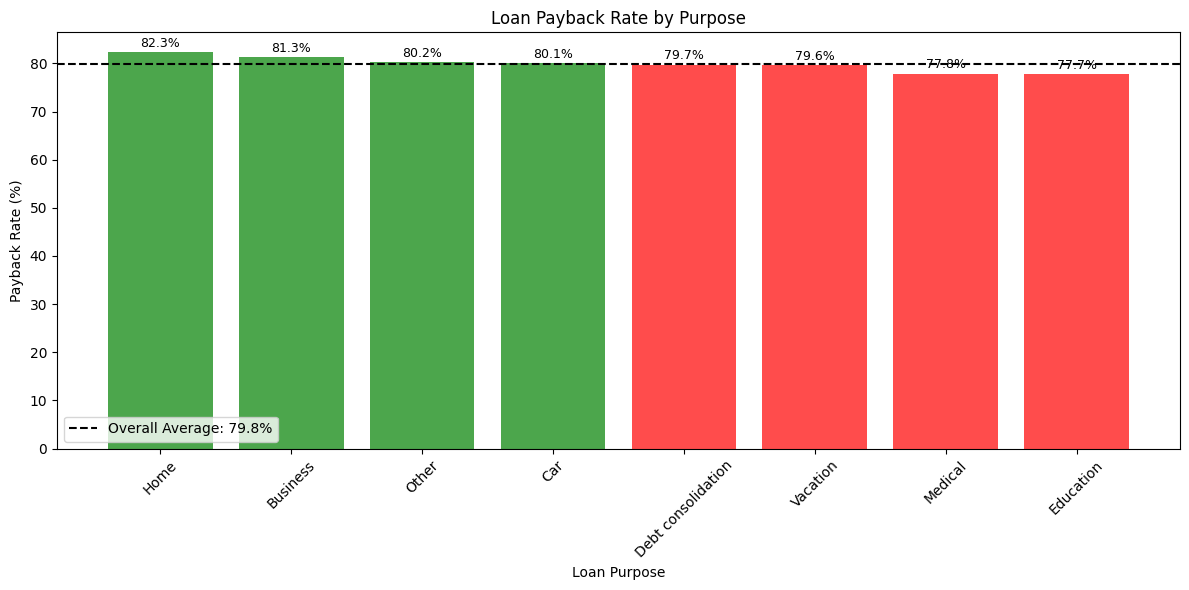

In [95]:
plt.figure(figsize=(12, 6))

payback_rates = train_df.groupby('loan_purpose')['loan_paid_back'].mean().sort_values(ascending=False)

colors = ['green' if rate > payback_rates.mean() else 'red' for rate in payback_rates]
bars = plt.bar(payback_rates.index, payback_rates.values * 100, color=colors, alpha=0.7)

plt.axhline(y=payback_rates.mean() * 100, color='black', linestyle='--', 
            label=f'Overall Average: {payback_rates.mean()*100:.1f}%')

plt.title('Loan Payback Rate by Purpose')
plt.xlabel('Loan Purpose')
plt.ylabel('Payback Rate (%)')
plt.xticks(rotation=45)
plt.legend()

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

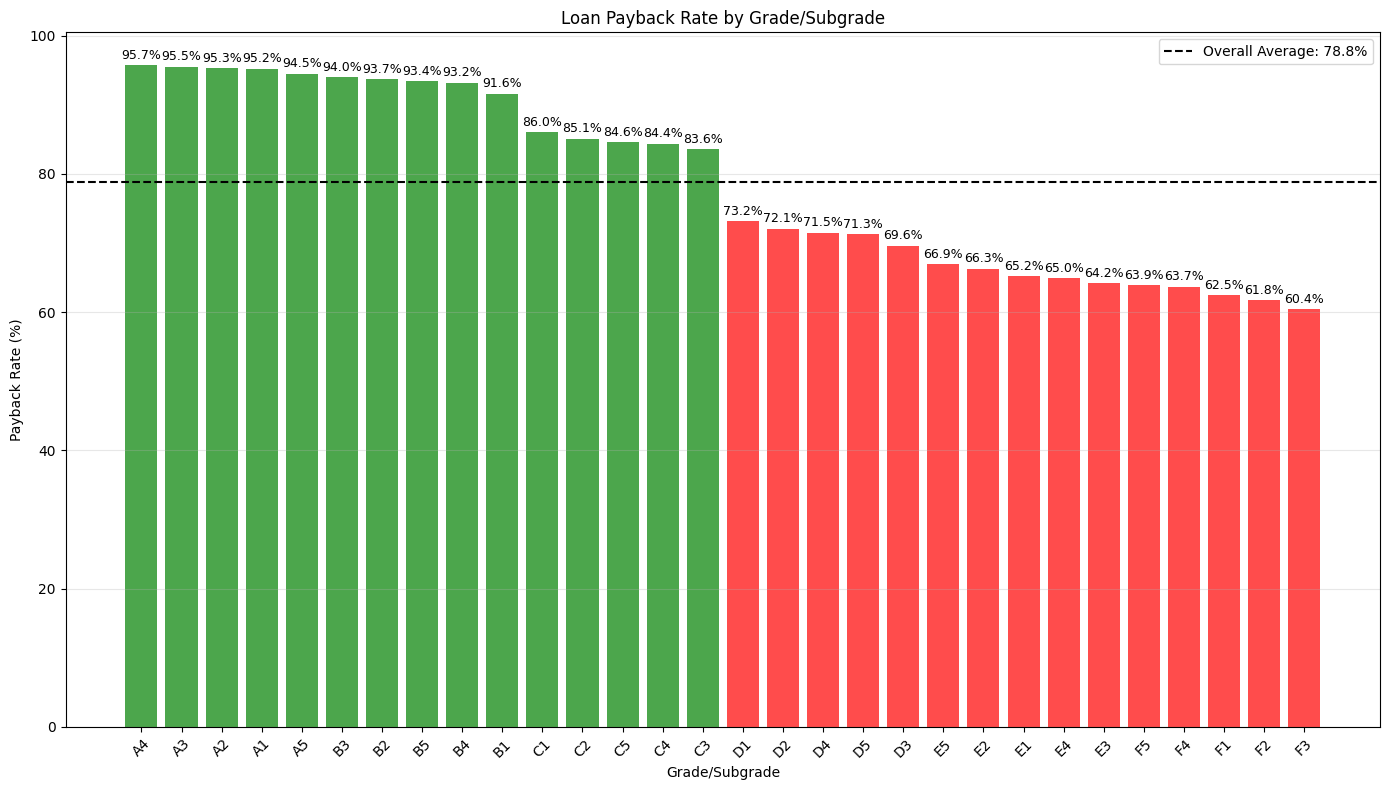

In [96]:
plt.figure(figsize=(14, 8))

# Calculate payback rate for each grade_subgrade
payback_rates = train_df.groupby('grade_subgrade')['loan_paid_back'].mean().sort_values(ascending=False)

# Create bar plot with colors
colors = ['green' if rate > payback_rates.mean() else 'red' for rate in payback_rates]
bars = plt.bar(payback_rates.index, payback_rates.values * 100, color=colors, alpha=0.7)

plt.axhline(y=payback_rates.mean() * 100, color='black', linestyle='--', 
            label=f'Overall Average: {payback_rates.mean()*100:.1f}%')

plt.title('Loan Payback Rate by Grade/Subgrade')
plt.xlabel('Grade/Subgrade')
plt.ylabel('Payback Rate (%)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [97]:
#ordinal encoding

education_map = {
    "Other" : 2, #medium risk
    "High School" : 3,
    "Bachelor's" : 2,
    "Master's" : 2,
    "PhD" : 1 #lower risk
}

train_df['education_level'] = train_df['education_level'].map(education_map)

relationship_map = {

    'Single': 1,
    'Divorced': 2, #higher risk
    'Married': 0,
    'Widowed': 0

}

train_df['marital_status'] = train_df['marital_status'].map(relationship_map)

employment_map = {
    'Employed' : 0,
    'Self-Employed' : 1
}

train_df['employment_status'] = train_df['employment_status'].map(employment_map)

purpose_map = {
    'Home': 0,
    'Business': 0,
    'Other': 1,
    'Car': 1,
    'Debt consolidation': 2,
    'Vacation': 2,
    'Medical': 3,
    'Education': 3
}

train_df['loan_purpose'] = train_df['loan_purpose'].map(purpose_map)

grade_map_performance = {

    'A1': 0, 'A2': 0, 'A3': 0, 'A4': 0, 'A5': 0, 
    
    'B1': 1, 'B2': 0, 'B3': 0, 'B4': 0,
    
    'C1': 1, 'C2': 1, 'C3': 1, 'C4': 1, 'C5': 1,
    
    'D1': 2, 'D2': 2, 'D3': 2, 'D4': 2, 'D5': 2,
    
    'E1': 3, 'E2': 3, 'E3': 3, 'E4': 3,

    'F1': 4, 'F2': 4, 'F3': 4, 'F4': 4, 'F5': 4
}

train_df['grade_subgrade'] = train_df['grade_subgrade'].map(grade_map_performance)

In [98]:
#ordinal encoding

education_map = {
    "Other" : 2, #medium risk
    "High School" : 3,
    "Bachelor's" : 2,
    "Master's" : 2,
    "PhD" : 1 #lower risk
}

test_df['education_level'] = test_df['education_level'].map(education_map)

relationship_map = {

    'Single': 1,
    'Divorced': 2, #higher risk
    'Married': 0,
    'Widowed': 0

}

test_df['marital_status'] = test_df['marital_status'].map(relationship_map)

employment_map = {
    'Employed' : 0,
    'Self-Employed' : 1
}

test_df['employment_status'] = test_df['employment_status'].map(employment_map)

purpose_map = {
    'Home': 0,
    'Business': 0,
    'Other': 1,
    'Car': 1,
    'Debt consolidation': 2,
    'Vacation': 2,
    'Medical': 3,
    'Education': 3
}

test_df['loan_purpose'] = test_df['loan_purpose'].map(purpose_map)

grade_map_performance = {

    'A1': 0, 'A2': 0, 'A3': 0, 'A4': 0, 'A5': 0, 
    
    'B1': 1, 'B2': 0, 'B3': 0, 'B4': 0,
    
    'C1': 1, 'C2': 1, 'C3': 1, 'C4': 1, 'C5': 1,
    
    'D1': 2, 'D2': 2, 'D3': 2, 'D4': 2, 'D5': 2,
    
    'E1': 3, 'E2': 3, 'E3': 3, 'E4': 3,

    'F1': 4, 'F2': 4, 'F3': 4, 'F4': 4, 'F5': 4
}

test_df['grade_subgrade'] = test_df['grade_subgrade'].map(grade_map_performance)

In [99]:
test_df

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,in_relationship,in_debt
0,28781.05,0.049,626,11461.42,14.73,Female,1,3,0.0,1,2.0,0,0
1,46626.39,0.093,732,15492.25,12.85,Female,0,2,0.0,1,1.0,1,0
2,54954.89,0.367,611,3796.41,13.29,Male,1,2,0.0,2,2.0,0,1
3,25644.63,0.110,671,6574.30,9.57,Female,1,2,0.0,2,1.0,0,1
4,25169.64,0.081,688,17696.89,12.80,Female,0,1,0.0,0,1.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
254564,92835.97,0.068,744,29704.00,13.48,Female,1,2,0.0,2,0.0,0,1
254565,48846.47,0.091,634,20284.33,9.58,Female,0,3,0.0,2,2.0,1,1
254566,20668.52,0.096,718,26387.55,9.00,Male,1,2,0.0,2,1.0,0,1
254567,34105.09,0.094,739,11107.36,9.81,Male,1,2,0.0,0,1.0,0,0


In [100]:
gender_encoded = pd.get_dummies(train_df['gender'], prefix='gender')

train_df = pd.concat([train_df, gender_encoded], axis=1)

print(train_df[['gender', 'gender_Female', 'gender_Male']])

        gender  gender_Female  gender_Male
0       Female           True        False
1         Male          False         True
2         Male          False         True
3       Female           True        False
4         Male          False         True
...        ...            ...          ...
593989  Female           True        False
593990    Male          False         True
593991  Female           True        False
593992    Male          False         True
593993    Male          False         True

[593994 rows x 3 columns]


In [101]:
gender_encoded = pd.get_dummies(test_df['gender'], prefix='gender')

test_df = pd.concat([test_df, gender_encoded], axis=1)

print(test_df[['gender', 'gender_Female', 'gender_Male']])

        gender  gender_Female  gender_Male
0       Female           True        False
1       Female           True        False
2         Male          False         True
3       Female           True        False
4       Female           True        False
...        ...            ...          ...
254564  Female           True        False
254565  Female           True        False
254566    Male          False         True
254567    Male          False         True
254568  Female           True        False

[254569 rows x 3 columns]


In [102]:
train_df = train_df.drop(columns='gender')
test_df = test_df.drop(columns='gender')

In [103]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   annual_income         593994 non-null  float64
 1   debt_to_income_ratio  593994 non-null  float64
 2   credit_score          593994 non-null  int64  
 3   loan_amount           593994 non-null  float64
 4   interest_rate         593994 non-null  float64
 5   marital_status        593994 non-null  int64  
 6   education_level       593994 non-null  int64  
 7   employment_status     450645 non-null  float64
 8   loan_purpose          593994 non-null  int64  
 9   grade_subgrade        573973 non-null  float64
 10  loan_paid_back        593994 non-null  float64
 11  in_relationship       593994 non-null  int64  
 12  in_debt               593994 non-null  int64  
 13  gender_Female         593994 non-null  bool   
 14  gender_Male           593994 non-null  bool   
 15  

In [104]:
from sklearn.model_selection import train_test_split

X = train_df.drop(columns='loan_paid_back')
y = train_df['loan_paid_back']

In [111]:
X_train = X_train.drop(columns='gender')
X_test = X_test.drop(columns='gender')

In [105]:
from sklearn.model_selection import cross_val_score

In [114]:
def objective(trial):
    """Optuna objective function for hyperparameter optimization"""

    params = {
        'objective': 'multi:softprob',
        'num_class': len(np.unique(y_train)),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 2),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 2),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 2),
        'random_state': 42,
        'use_label_encoder': False,
        'eval_metric': 'mlogloss',
        'tree_method': 'hist',
        'device': "cuda"
    }

    model = XGBClassifier(**params)

    cv_scores = cross_val_score(model, X_train, y_train, cv=3, scoring='neg_log_loss')

    return np.median(cv_scores)


study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print("Best parameters:", study.best_params)
print("Best CV score:", study.best_value)

[I 2025-11-16 15:38:55,654] A new study created in memory with name: no-name-bb75a831-1022-491d-80e8-06b078695a47
[I 2025-11-16 15:39:05,945] Trial 0 finished with value: -0.33548866335917266 and parameters: {'n_estimators': 120, 'max_depth': 8, 'learning_rate': 0.03926695341191348, 'subsample': 0.9204672055557346, 'colsample_bytree': 0.618290042408105, 'min_child_weight': 1, 'gamma': 1.4086501830536355, 'reg_alpha': 0.1256544921684708, 'reg_lambda': 1.8544731527566223}. Best is trial 0 with value: -0.33548866335917266.
[I 2025-11-16 15:39:40,841] Trial 1 finished with value: -0.3359195634642051 and parameters: {'n_estimators': 473, 'max_depth': 5, 'learning_rate': 0.014695369579818722, 'subsample': 0.6160604792625629, 'colsample_bytree': 0.6960887405608525, 'min_child_weight': 1, 'gamma': 1.0552992295935055, 'reg_alpha': 0.8390991912081489, 'reg_lambda': 1.741317494415166}. Best is trial 0 with value: -0.33548866335917266.
[I 2025-11-16 15:40:05,851] Trial 2 finished with value: -0.33

Best parameters: {'n_estimators': 448, 'max_depth': 5, 'learning_rate': 0.09845961376837378, 'subsample': 0.6981342521411485, 'colsample_bytree': 0.9069331921390967, 'min_child_weight': 9, 'gamma': 0.8495227875227105, 'reg_alpha': 1.0350487330395224, 'reg_lambda': 0.3636988508454906}
Best CV score: -0.3297986541265725


In [115]:
xgb_params = {
    'n_estimators': 448,
 'max_depth': 5,
 'learning_rate': 0.09845961376837378,
 'subsample': 0.6981342521411485,
 'colsample_bytree': 0.9069331921390967,
 'min_child_weight': 9,
 'gamma': 0.8495227875227105,
 'reg_alpha': 1.0350487330395224,
 'reg_lambda': 0.3636988508454906
}

xgb_model = XGBClassifier(**xgb_params)
cv_res = cross_val_score(xgb_model, X_train, y_train, cv=3, scoring='neg_log_loss')

print(f"Final CV scores: {cv_res}")
print(f"Mean CV score: {cv_res.mean():.4f} ± {cv_res.std():.4f}")

xgb_model.fit(X_train, y_train)

Final CV scores: [-0.32990598 -0.3301284  -0.32931209]
Mean CV score: -0.3298 ± 0.0003


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9069331921390967
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [ ]:
# X_submission = test_df.copy()

# xgb_preds = xgb_model.predict(X_submission)

# xgb_df = pd.DataFrame({
#     'id' : test_id_placeholder,
#     'loan_paid_back' : xgb_preds
# })

# xgb_df.to_csv("xgb_preds1.csv", index= False)

# print("Success!")

Success!
